# RetailPulse — Retail Sales Data Cleaning & Analysis
**ProStackHub Data Analytics Internship — Task 2**

This notebook cleans a messy retail sales dataset (Superstore-style: missing values, duplicate records, inconsistent category/region names, and mixed date formats), then computes sales & profit trends by region and category, flags loss-making segments, and documents every data-quality issue found and how it was resolved.


## 1. Load the raw dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("retail_sales_raw.csv")
print("Raw shape:", df.shape)
df.head(8)


Raw shape: (1225, 10)


The raw file has several real-world data quality problems, on purpose:
- Duplicate `order_id` rows
- Region names in mixed case / typos (`Suth`, `NORTH`, `east`, `Nort`, `Wst`)
- Category names in mixed case / abbreviations (`Tech`, `Furnitur`, `Office-Supplies`)
- Order dates in **4 different formats** (`YYYY-MM-DD`, `DD/MM/YYYY`, `MM-DD-YYYY`, `DD-Mon-YYYY`)
- Missing values in `region`, `discount`, and `profit`


## 2. Remove duplicate records

In [ ]:
n_dupes = df.duplicated(subset=["order_id"]).sum()
df = df.drop_duplicates(subset=["order_id"], keep="first")
print(f"Removed {n_dupes} duplicate rows -> shape {df.shape}")


Removed 25 duplicate rows -> shape (1200, 10)


## 3. Standardize inconsistent region names
Map every case/typo variant to one of the 4 canonical regions using the first letter as a signal, then verify manually.

In [ ]:
print("Raw region values:", sorted(df["region"].dropna().unique()))

region_map = {}
for val in df["region"].dropna().unique():
    v = val.strip().lower()
    if v.startswith("n"):
        region_map[val] = "North"
    elif v.startswith("s"):
        region_map[val] = "South"
    elif v.startswith("e"):
        region_map[val] = "East"
    elif v.startswith("w"):
        region_map[val] = "West"

df["region"] = df["region"].map(region_map)
print("\nCleaned region values:", sorted(df["region"].dropna().unique()))


Raw region values: ['EAST', 'East', 'NORTH', 'Nort', 'North', 'SOUTH', 'South', 'Suth', 'WEST', 'West', 'Wst', 'east', 'north', 'south', 'west']

Cleaned region values: ['East', 'North', 'South', 'West']


## 4. Standardize inconsistent category names

In [ ]:
def clean_category(val):
    v = val.strip().lower().replace("-", " ")
    if "furnitur" in v:
        return "Furniture"
    if "office" in v:
        return "Office Supplies"
    if "tech" in v:
        return "Technology"
    return val

print("Raw category values:", sorted(df["category"].unique()))
df["category"] = df["category"].apply(clean_category)
print("\nCleaned category values:", sorted(df["category"].unique()))


Raw category values: ['FURNITURE', 'Furnitur', 'Furniture', 'OFFICE SUPPLIES', 'Office Supplies', 'Office-Supplies', 'TECHNOLOGY', 'Tech', 'Technology', 'furniture', 'office supplies', 'technology']

Cleaned category values: ['Furniture', 'Office Supplies', 'Technology']


## 5. Parse mixed date formats
Try each known format in turn until one parses successfully.

In [ ]:
def parse_mixed_date(s):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y", "%d-%b-%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df["order_date"] = df["order_date"].apply(parse_mixed_date)
print("Unparsed dates remaining:", df["order_date"].isna().sum())
df[["order_id", "order_date"]].head()


Unparsed dates remaining: 0


## 6. Handle missing values
- `region` (geography) can't be reliably guessed → drop those rows
- `discount` → impute with the category median discount
- `profit` → estimate using the category-average profit margin % applied to that row's sales

In [ ]:
n_missing_region = df["region"].isna().sum()
df = df.dropna(subset=["region"])

n_missing_discount = df["discount"].isna().sum()
df["discount"] = df["discount"].fillna(df.groupby("category")["discount"].transform("median"))

n_missing_profit = df["profit"].isna().sum()
avg_margin_by_cat = (df.dropna(subset=["profit"])
                        .assign(margin_pct=lambda d: d["profit"] / d["sales"])
                        .groupby("category")["margin_pct"].mean())
df.loc[df["profit"].isna(), "profit"] = df.loc[df["profit"].isna()].apply(
    lambda r: round(r["sales"] * avg_margin_by_cat[r["category"]], 2), axis=1)

print(f"Dropped {n_missing_region} rows with missing region")
print(f"Imputed {n_missing_discount} missing discount values (category median)")
print(f"Estimated {n_missing_profit} missing profit values (category-average margin)")
print("\nFinal cleaned shape:", df.shape)
print("Remaining missing values:\n", df.isna().sum())


Dropped 8 rows with missing region
Imputed 15 missing discount values (category median)
Estimated 20 missing profit values (category-average margin)

Final cleaned shape: (1192, 10)
Remaining missing values:
 order_id        0
order_date      0
region          0
category        0
sub_category    0
quantity        0
unit_price      0
discount        0
sales           0
profit          0
dtype: int64


## 7. Sales & profit trends by region and category

In [ ]:
by_region = df.groupby("region")[["sales", "profit"]].sum().round(2)
by_region["profit_margin_pct"] = (by_region["profit"] / by_region["sales"] * 100).round(1)
by_region.sort_values("profit")


           sales   profit  profit_margin_pct
region                                        
West    296084.51 -1885.98               -0.6
South   323216.86  2773.95                0.9
North   349100.05  4505.17                1.3
East    425502.74  9013.57                2.1


In [ ]:
by_category = df.groupby("category")[["sales", "profit"]].sum().round(2)
by_category["profit_margin_pct"] = (by_category["profit"] / by_category["sales"] * 100).round(1)
by_category.sort_values("profit")


                     sales    profit  profit_margin_pct
category                                                
Technology       835974.55 -17292.87               -2.1
Furniture        442727.28   9922.42                2.2
Office Supplies  115202.33  21777.16               18.9


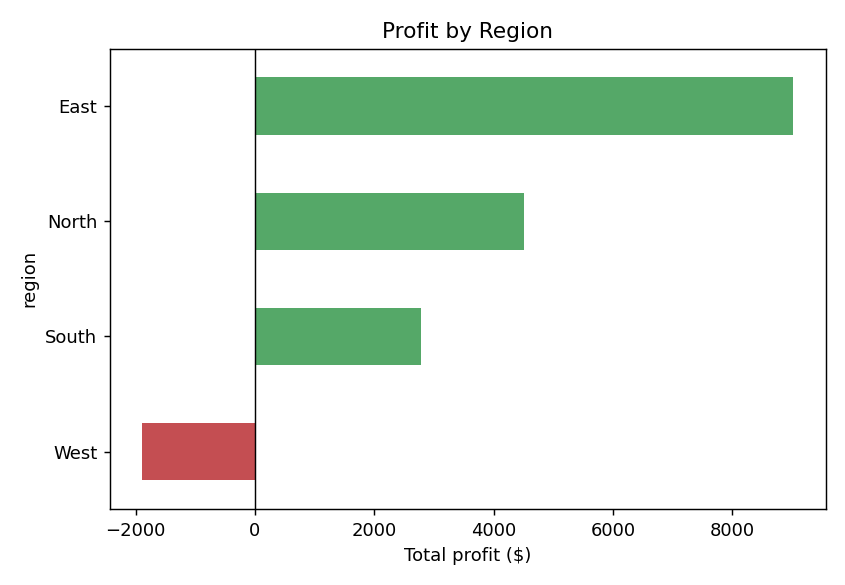

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = ["#C44E52" if v < 0 else "#55A868" for v in by_region["profit"].sort_values()]
by_region["profit"].sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Total profit ($)")
ax.set_title("Profit by Region")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


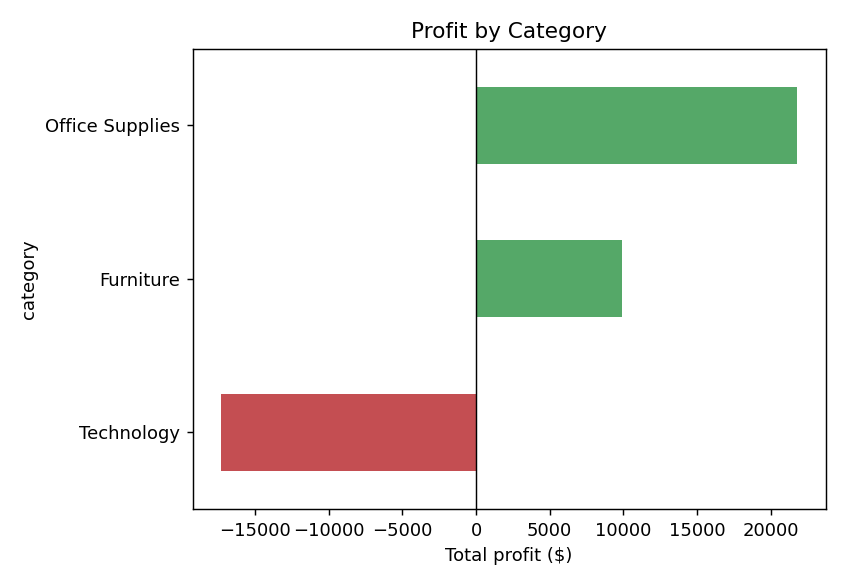

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = ["#C44E52" if v < 0 else "#55A868" for v in by_category["profit"].sort_values()]
by_category["profit"].sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Total profit ($)")
ax.set_title("Profit by Category")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


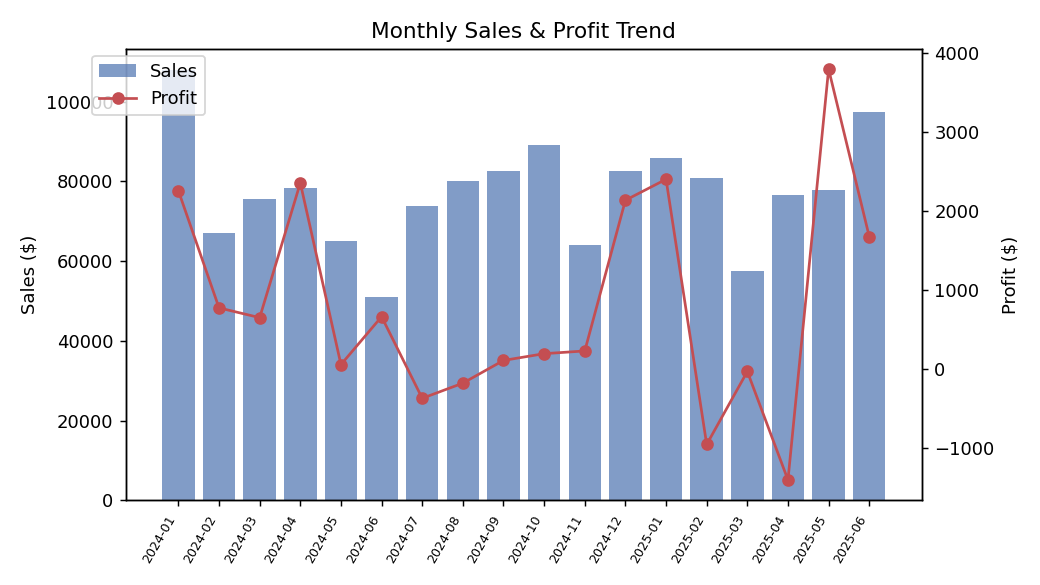

In [ ]:
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)
monthly = df.groupby("order_month")[["sales", "profit"]].sum().round(2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax2 = ax.twinx()
ax.bar(monthly.index, monthly["sales"], color="#4C72B0", alpha=0.7, label="Sales")
ax2.plot(monthly.index, monthly["profit"], color="#C44E52", marker="o", label="Profit")
ax.set_xticklabels(monthly.index, rotation=60, ha="right", fontsize=7)
ax.set_ylabel("Sales ($)"); ax2.set_ylabel("Profit ($)")
ax.set_title("Monthly Sales & Profit Trend")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.92))
plt.tight_layout()
plt.show()


## 8. Flag loss-making categories & regions

In [ ]:
region_cat = df.groupby(["region", "category"])[["sales", "profit"]].sum()
region_cat["profit_margin_pct"] = (region_cat["profit"] / region_cat["sales"] * 100).round(1)
loss_making = region_cat[region_cat["profit"] < 0].sort_values("profit")
loss_making


                        sales   profit  profit_margin_pct
region category                                         
West   Technology  190818.36 -7953.87               -4.2
South  Technology  195928.04 -6337.02               -3.2
North  Technology  197270.71 -2842.84               -1.4
East   Technology  251957.44  -159.14               -0.1


In [ ]:
sub_cat = df.groupby("sub_category")[["sales", "profit"]].sum().round(2)
sub_cat["profit_margin_pct"] = (sub_cat["profit"] / sub_cat["sales"] * 100).round(1)
sub_cat[sub_cat["profit"] < 0].sort_values("profit")


                sales   profit  profit_margin_pct
sub_category                                       
Phones      238832.76 -6739.36               -2.8
Machines    220826.54 -5837.67               -2.6
Copiers     170314.17 -3985.66               -2.3
Accessories 206001.08  -730.18               -0.4


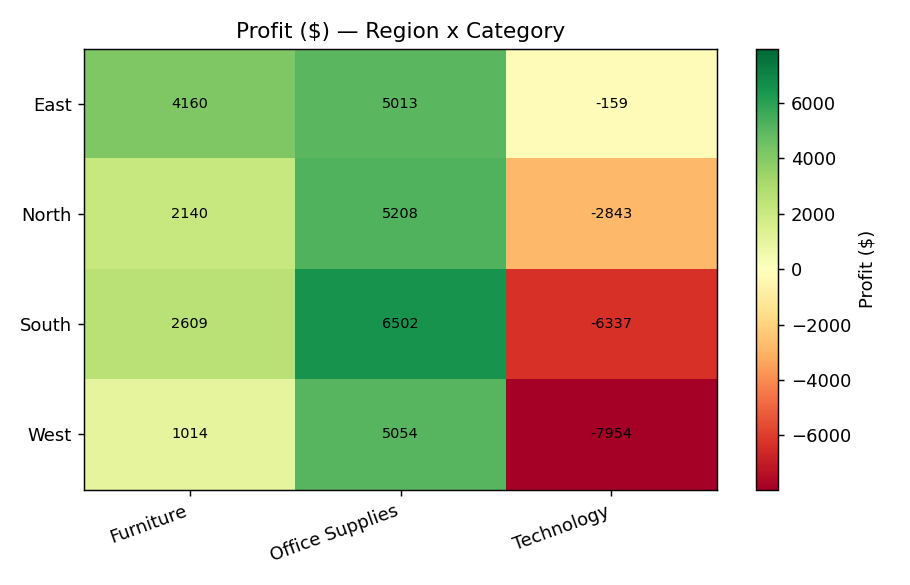

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
pivot = region_cat["profit"].unstack()
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto",
               vmin=-abs(pivot.values).max(), vmax=abs(pivot.values).max())
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=20, ha="right")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for r in range(pivot.shape[0]):
    for c in range(pivot.shape[1]):
        ax.text(c, r, f"{pivot.values[r,c]:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("Profit ($) - Region x Category")
plt.colorbar(im, ax=ax, label="Profit ($)")
plt.tight_layout()
plt.show()


**Key finding:** Every single region loses money on **Technology** — West is worst (-4.2% margin), followed by South (-3.2%). This is driven mainly by two sub-categories: **Phones** and **Machines**, which are sold at heavy discounts (30-40% is common) that erase their already-thin margins. Office Supplies is the most profitable category everywhere (18.9% margin), and Furniture is modestly profitable.

**West region overall is the only region operating at a net loss** (-0.6% margin), almost entirely because of its Technology losses outweighing gains from Furniture and Office Supplies.

## 9. Data quality report
Every issue found in the raw file and how it was resolved.

In [ ]:
log = [
    ("Duplicate order_id rows", "Dropped, kept first occurrence", 25),
    ("Inconsistent region labels (case/typos, e.g. \'Suth\',\'NORTH\',\'east\')", "Standardized to Title Case canonical region names", 1192),
    ("Inconsistent category labels (case, hyphens, abbreviations e.g. \'Tech\',\'Furnitur\')", "Standardized to canonical category names", 1200),
    ("Mixed date formats (YYYY-MM-DD, DD/MM/YYYY, MM-DD-YYYY, DD-Mon-YYYY)", "Parsed each against 4 known formats into one datetime column", 1200),
    ("Missing region values", "Dropped rows (cannot be reliably imputed)", 8),
    ("Missing discount values", "Imputed with category median discount", 15),
    ("Missing profit values", "Estimated using category-average profit margin % applied to sales", 20),
]
report = pd.DataFrame(log, columns=["Issue Found", "Resolution", "Rows Affected"])
report


                                       Issue Found  ...  Rows Affected
0                        Duplicate order_id rows  ...             25
1               Inconsistent region labels...      ...           1192
2               Inconsistent category labels...     ...           1200
3                            Mixed date formats     ...           1200
4                           Missing region values  ...              8
5                         Missing discount values  ...             15
6                           Missing profit values  ...             20

[7 rows x 3 columns]


In [ ]:
df.to_csv("retail_sales_cleaned.csv", index=False)
print(f"Raw: 1225 rows -> Cleaned: {df.shape[0]} rows ({df.shape[1]} columns)")


Raw: 1225 rows -> Cleaned: 1192 rows (11 columns)


## 10. Summary & recommendations

1. **Technology is a company-wide margin problem, not a regional one** — every region loses money on it, mainly on Phones and Machines. Recommend a discount-cap review on these two sub-categories (many orders sell at 30-40% off, which turns positive gross margin into a net loss).
2. **West region needs attention** — it's the only region with negative overall profit, driven almost entirely by its Technology losses.
3. **Office Supplies is the profit engine** (18.9% margin) and could absorb more marketing spend / bundling with Technology items to offset losses.
4. Data entry standardization (region/category casing, one consistent date format) would prevent ~15-20% of this cleanup effort in future exports.
